***Alexandre Mathias DONNAT, Télécom Paris***

# Machine Translation with Seq2seq models via Pytorch

The goal of this lab are to:
- Familiarize ourself with the task of **Machine Translation (MT)**
- Implement a basic **recurrent sequence-to-sequence** model in Pytorch
- Train the model on a very simple English-French MT dataset
- Implement an **attention** module into the model and visualize its results

We will **for most of this lab** focus on the model and leave aside what are normally very important aspects of Machine Learning methodology: in particular, we won't use validation and test data to search for hyperparameter search. We will **split the data and retrain the model at the end of the lab** for a comparative performance evaluation.

In [68]:
# General stuff
from io import open
import re
import random
import numpy as np
import matplotlib.pyplot as plt

# Nice printing
from pprint import pprint

# Pytorch
import torch
import torch._utils
import torch.nn as nn
from torch import optim
from torch.nn import functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

import importlib

torch._utils = importlib.import_module("torch._utils")

print(hasattr(torch, "_utils"))

# Which device to use ?
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


### I Dataset and pre-processing

We're going to work with data from the **tatoeba** website. This website proposes human-made translations for many (relatively) simple sentences, with sometimes several possible translations for one sentence.
Pre-processed versions of the *tatoeba dataset* can be found on this [website](https://www.manythings.org/anki/). You are given the 'English $\rightarrow$ French' data already cleaned, but you are free to use any other language you would prefer.  


<div class='alert alert-block alert-warning'>
            Question:</div>
            
We will define these as global variables - for convenience. Given what was said in class and how they are employed in this lab, explain briefly what each one is used for.

In [69]:
# Some global variables
PAD_TOKEN = 0
SOS_TOKEN = 1
EOS_TOKEN = 2

`PAD_TOKEN = 0` is used for padding. Since sentences in a batch can have different lengths, shorter sequences are completed with this token so that all tensors have the same length. It should not carry linguistic meaning and is usually ignored in the loss.

`SOS_TOKEN = 1` stands for “Start Of Sentence”. It is given as the first input to the decoder to indicate that it should start generating the translated sentence.

`EOS_TOKEN = 2` stands for “End Of Sentence”. It marks the end of a sequence. During training, it tells the model where the target sentence ends, and during inference, generation can stop when the decoder predicts this token.

From the previous pytorch lab, we know we will require to define some parameters. We can already choose the maximum length of sequences, the size of our batches, and the internal dimension used by our model. Note that the length of sequence is rather short in this data - you can take a look at the histogram.

**Put ```fra.txt``` in the current directory**.

In [70]:
# Parameters
max_length = 10
batch_size = 32
hidden_size = 128

In [71]:
# Read the file and split into lines
parallel = open('fra.txt', encoding='utf-8').\
        read().strip().split('\n')

In [72]:
# Data looks like this
pprint(parallel[0:5])

['Go.\tVa !\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & '
 '#1158250 (Wittydev)',
 'Go.\tMarche.\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & '
 '#8090732 (Micsmithel)',
 'Go.\tEn route !\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & '
 '#8267435 (felix63)',
 'Go.\tBouge !\tCC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & '
 '#9022935 (Micsmithel)',
 'Hi.\tSalut !\tCC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & '
 '#509819 (Aiji)']


We will need to clean this up. Use the regular expression package ```re``` to remove any non letter character. Be careful, though, with French, you need to keep the accents. We will then organize the data into pairs, as is usual in MT.

<div class='alert alert-block alert-info'>
            Code:</div>

In [73]:
# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    s = s.lower().strip()
    s = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [74]:
# Split every line into pairs and normalize
pairs = [[normalizeString(s) for s in l.split('\t')[:2]] for l in parallel]

In [75]:
pprint(pairs[0:5])

[['go', 'va'],
 ['go', 'marche'],
 ['go', 'en route'],
 ['go', 'bouge'],
 ['hi', 'salut']]


Begin with implementing a class ```Vocab``` that will accumulate counts and indexes of words into language-specific dictionnaries. In this case, we would like the vocabulary to be built on the fly, to work well with the format of our data (parallel sentences from both languages).

<div class='alert alert-block alert-info'>
            Code:</div>

In [76]:
class Vocab:
    def __init__(self):
        self.word2count = {}
        self.word2idx = {
            "PAD": PAD_TOKEN,
            "SOS": SOS_TOKEN,
            "EOS": EOS_TOKEN
        }
        self.idx2word = {
            PAD_TOKEN: "PAD",
            SOS_TOKEN: "SOS",
            EOS_TOKEN: "EOS"
        }

    def addWord(self, word):
        if word not in self.word2idx:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
            self.word2count[word] = 1
        else:
            self.word2count[word] = self.word2count.get(word, 0) + 1

    # Implemented assuming we will process lines one by one, easier given the format of our data
    def addSent(self, sent):
        for word in sent.split(" "):
            if word != "":
                self.addWord(word)

    def __len__(self):
        return len(self.word2idx)

Then, create a function ```tensorFromSentence``` that will take an untokenized sentence (hence, a string), a ```Vocab``` object, and the ```max_length``` parameter as inputs, and return a ```LongTensor``` representing the sequence of indexes.

<div class='alert alert-block alert-info'>
            Code:</div>

In [77]:
def tensorFromSentence(sent, vocab, max_length):
    indexes = [vocab.word2idx[word] for word in sent.split(" ") if word != ""]
    indexes.append(EOS_TOKEN)

    if len(indexes) > max_length:
        indexes = indexes[:max_length]
        indexes[-1] = EOS_TOKEN

    while len(indexes) < max_length:
        indexes.append(PAD_TOKEN)

    return torch.LongTensor(indexes)

Finally, complete this ```TranslationDataset``` class inheriting from ```Dataset```. It should, from the list of parallel sentences:
- Apply an optional filter to possibly reduce the dataset size and complexity,
- Instantiate and build ```Vocab``` objects for both languages,
- Create two lists containing ```LongTensor``` objects for each language,
- Group them into two tensors of the appropriate size with ```pad_sequence```.

We should note that, depending on the ordering of the pairs, one language will be the **source**, and the other will be the **target** of our model. In this case, English is the source and French the target.
<div class='alert alert-block alert-info'>
            Code:</div>

In [78]:
class TranslationDataset(Dataset):
    def __init__(self, parallel_data, max_length=10, filter_target_prefixes=None):
        # We will select some subset on the data to avoid having too much
        self.pairs = self.filterData(parallel_data, filter_target_prefixes)

        # Creating both vocabularies
        self.max_length = max_length
        self.input_lang = Vocab()
        self.output_lang = Vocab()

        # Filling both vocabularies
        for input_sent, output_sent in self.pairs:
            self.input_lang.addSent(input_sent)
            self.output_lang.addSent(output_sent)

        # List of tensors to be created
        input_tensors = []
        output_tensors = []

        for input_sent, output_sent in self.pairs:
            input_tensors.append(tensorFromSentence(input_sent, self.input_lang, max_length))
            output_tensors.append(tensorFromSentence(output_sent, self.output_lang, max_length))

        # Put them all at the same size with pad_sequence
        self.tensor_inputs = pad_sequence(
            input_tensors,
            batch_first=True,
            padding_value=PAD_TOKEN
        )

        self.tensor_outputs = pad_sequence(
            output_tensors,
            batch_first=True,
            padding_value=PAD_TOKEN
        )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        # The iterator just gets one particular example
        # The dataloader will take care of the shuffling and batching
        if torch.is_tensor(idx):
            idx = idx.tolist()
        return self.tensor_inputs[idx], self.tensor_outputs[idx]

    def filterPair(self, pair, prefixes):
        return pair[0].startswith(prefixes)

    def filterData(self, pairs, filter_target_prefixes):
        if filter_target_prefixes is not None:
            return [pair for pair in pairs if self.filterPair(pair, filter_target_prefixes)]
        else:
            return pairs

Create a ```TranslationDataset``` from our data, with no filter, and look at its size, and the sizes of the vocabularies. What could be a problem here ?

<div class='alert alert-block alert-warning'>
            Question:</div>

Without filtering, the dataset is quite large and the vocabularies are also large. This can make training slower and harder, especially for a simple seq2seq model. Many words will appear only a few times, which increases sparsity and makes the model harder to train. Also, with a fixed `max_length`, some sentences may be truncated, so part of the information can be lost.

We will now use a filter: we will only consider pairs of sentences which English begins with chains of characters from the ```prefixes``` set.

- Create the dataset with this filter.
- Look at the sizes involved.
- **Split the data and keep a small subset for testing** (done at the end of the lab)
- Create a dataloader with the previously defined ```batch_size```.

<div class='alert alert-block alert-info'>
            Code:</div>

In [79]:
# Consider only the sentences beginning with these
prefixes = ("i am ", "i m ",
            "he is", "he s ",
            "she is", "she s ",
            "you are", "you re ",
            "we are", "we re ",
            "they are", "they re ")

# New dataset:
dataset = TranslationDataset(
    pairs,
    max_length=max_length,
    filter_target_prefixes=prefixes
)

print("Dataset size:", len(dataset))
print("Input vocabulary size:", len(dataset.input_lang))
print("Output vocabulary size:", len(dataset.output_lang))
print("First example:", dataset[0])

Dataset size: 21733
Input vocabulary size: 4310
Output vocabulary size: 6708
First example: (tensor([3, 4, 5, 2, 0, 0, 0, 0, 0, 0]), tensor([3, 4, 5, 2, 0, 0, 0, 0, 0, 0]))


In [80]:
# Split the dataset and keep a small subset for testing
test_size = min(1000, int(0.1 * len(dataset)))
train_size = len(dataset) - test_size

training_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, test_size]
)

print("Training size:", len(training_dataset))
print("Test size:", len(test_dataset))

Training size: 20733
Test size: 1000


In [81]:
# Creating the dataloader
training_dataloader = DataLoader(
    training_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [82]:
input_batch, output_batch = next(iter(training_dataloader))

print(input_batch.shape)
print(output_batch.shape)

torch.Size([32, 10])
torch.Size([32, 10])


### II - Sequence to sequence architecture and training

We will now create two pytorch objects, which will inherit from ```Module```: the ```EncoderRNN``` and the ```DecoderRNN``` classes. Both are based on RNNs; we will use the lighter ```GRU``` (gated recurrent unit) recurrent layer.
While we won't check it with validation data, we should try to avoid overfitting with ```Dropout```.

Begin by completing the **encoder**. It uses an ```Embedding``` layer, which has as many vectors as the size of the **source** vocabularies, plus the ```GRU```. Both embeddings and the recurrent layer use dimension ```hidden_size```. It should output two things:
- A sequence of vectors, corresponding to the representations of each input word that has gone through the encoder,
- The last hidden state used by the GRU of the encoder.

**Important**: with our first decoder, we will only use the **last hidden state**. However, we can still add the sequence of representations to the outputs, as we will need it for the *attention module* later.

<div class='alert alert-block alert-info'>
            Code:</div>

In [83]:
# Create encoder
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_TOKEN)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)

        return output, hidden

Next, we will need to complete the **decoder**. Besides the ```Embedding``` (for the **target** language) and ```GRU```, it needs an additional layer: a ```Linear``` layer to obtain output scores for the next word to be predicted.
The ```forward``` function is however a little more complicated: we will need it to be able to re-use what was predicted at the previous step during inference. Therefore, we will use the old-fashioned way: a **loop**. To summarize, we will:
- Create an empty tensor containing only the first token of the output sequence (*which is ?*) with ```torch.empty```.
- If we are in training mode, we can fill out that tensor with what we know to be the rest of the output sequence, make it go through the recurrent layer, and obtain scores.
- If we are in inference mode, we need to make a prediction at each step to re-insert the corresponding index as input afterwards. We can use the ```topk``` method to get the best index directly ! **Important:** use the ```detach()``` method to cut this from the computational graph.  

In both cases, we loop through the sequence and apply the same operations, which are in ```forward_step```. We return the log-probabilities of prediction at each step.

**Important:** Again, we also return an empty placeholder variable which we will later use for attention.

<div class='alert alert-block alert-info'>
            Code:</div>

In [84]:
# Create decoder
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_TOKEN)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, max_length, target_tensor=None):
        # We build the decoder the old school way
        batch_size = encoder_outputs.size(0)

        # First decoder input is SOS
        decoder_input = torch.empty(
            batch_size, 1,
            dtype=torch.long,
            device=device
        ).fill_(SOS_TOKEN)

        # First decoder hidden state comes from encoder final hidden state
        decoder_hidden = encoder_hidden

        decoder_outputs = []

        # Looping on the output sequence
        for i in range(max_length):
            decoder_output, decoder_hidden = self.forward_step(
                decoder_input,
                decoder_hidden
            )

            decoder_outputs.append(decoder_output)

            # Training mode: teacher forcing
            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)

            # Inference mode: use model prediction
            else:
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        # Concatenate outputs on sequence dimension
        decoder_outputs = torch.cat(decoder_outputs, dim=1)

        # Log probabilities over target vocabulary
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)

        return decoder_outputs, decoder_hidden, None

    def forward_step(self, input, hidden):
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)

        return output, hidden

Create an instance of one ```EncoderRNN``` and one ```DecoderRNN```. In order to do this, get the vocabulary sizes for the appropriate languages from the ```TranslationDataset``` object.

<div class='alert alert-block alert-info'>
            Code:</div>

In [85]:
input_size = len(dataset.input_lang)
output_size = len(dataset.output_lang)

encoder = EncoderRNN(input_size, hidden_size).to(device)
decoder = DecoderRNN(hidden_size, output_size).to(device)

print(encoder)
print(decoder)

EncoderRNN(
  (embedding): Embedding(4310, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
DecoderRNN(
  (embedding): Embedding(6708, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True)
  (out): Linear(in_features=128, out_features=6708, bias=True)
)


Implement the training loop into the ```train_epoch``` function. Follow the model from the previous lab. Note that we will use separated *optimizers* for the encoder and decoder. **Be careful to the sizes of the model outputs for use with the criterion !**

<div class='alert alert-block alert-info'>
            Code:</div>

In [86]:
def train_epoch(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    total_loss = 0

    encoder.train()
    decoder.train()

    for data in dataloader:
        input_tensor, target_tensor = data
        input_tensor = input_tensor.to(device)
        target_tensor = target_tensor.to(device)

        # Initiate gradient
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        # Forward
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(
            encoder_outputs,
            encoder_hidden,
            target_tensor.size(1),
            target_tensor
        )

        # Compute loss
        # decoder_outputs: [batch_size, seq_len, output_vocab_size]
        # target_tensor:    [batch_size, seq_len]
        loss = criterion(
            decoder_outputs.reshape(-1, decoder_outputs.size(-1)),
            target_tensor.reshape(-1)
        )

        # Compute gradient
        loss.backward()

        # Update weights
        encoder_optimizer.step()
        decoder_optimizer.step()

        # Keep track of loss
        total_loss += loss.item()

    return total_loss / len(dataloader)

We can know simply loop on this using the following function:

In [87]:
def train(train_dataloader, encoder, decoder, n_epochs=80, learning_rate=0.001, print_every=10, plot_every=10):
    encoder.train()
    decoder.train()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every
    # Initialize optimizers
    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    # Initialize criterion
    criterion = nn.NLLLoss()
    # Training loop
    for epoch in range(n_epochs):
        loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if (epoch + 1) % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('(%d %d%%) %.4f' % (epoch, epoch / n_epochs * 100, print_loss_avg))

        if (epoch + 1) % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

And we need to also implement an ```evaluate``` function. Here, we will need to use the decoder in **inference** node, so it will re-use what output it generates to continue processing. We will then transform this sequence of outputs into **words**. What is the stopping condition for our model generating words ?

<div class='alert alert-block alert-info'>
            Code:</div>

In [88]:
def evaluate(encoder, decoder, sentence, max_length, input_lang, output_lang):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        # One example to evaluate
        # We need to make it into a batch of one example to respect tensor dimensions
        input_tensor = tensorFromSentence(sentence, input_lang, max_length).view(1, -1).to(device)

        # Forward
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(
            encoder_outputs,
            encoder_hidden,
            max_length
        )

        # Get best output
        topv, topi = decoder_outputs.topk(1, dim=-1)
        decoded_ids = topi.squeeze(0).squeeze(-1).tolist()

        # Decode until stopping condition
        decoded_words = []
        for idx in decoded_ids:
            if idx == EOS_TOKEN:
                decoded_words.append("EOS")
                break
            else:
                decoded_words.append(output_lang.idx2word[idx])

    return decoded_words, decoder_attn

Let's use this function to evaluate our model on a random subset of the training data:

In [89]:
def evaluateRandomly(encoder, decoder, dataset, n=10):
    # do n examples
    for i in range(n):
        # select one from the known data to avoid vocabulary issue
        pair = random.choice(dataset.pairs)
        print('>', pair[0])
        print('=', pair[1])

        output_words, _ = evaluate(encoder, decoder, pair[0], dataset.max_length, dataset.input_lang, dataset.output_lang)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

Now, execute the training loop for, and look at what it generates. It should be fast on a cpu, and not take too long on a GPU.

<div class='alert alert-block alert-info'>
            Code:</div>

In [ ]:
train(training_dataloader, encoder, decoder, print_every=5, plot_every=5)
evaluateRandomly(encoder, decoder, training_dataset)

In [108]:
evaluateRandomly(encoder, decoder, dataset)

> you re invited
= tu es invitée
< vous êtes invité EOS

> i m ready to make amends
= je suis disposée à me repentir
< je suis disposée à me repentir EOS

> you re wearing too much perfume
= tu es trop parfumé
< tu es trop parfumé EOS

> we re talking about tom not mary
= c est de tom qu on parle pas de marie
< c est de la même taille que ce EOS

> i m worried about the baby
= je suis inquiète pour le bébé
< je suis inquiet pour le bébé EOS

> you re shivering
= vous tremblez
< tu frissonnes EOS

> you re really selfish
= vous êtes vraiment égoïstes
< vous êtes vraiment égoïstes EOS

> i m growing tired of all this arguing
= toutes ces disputes commencent à me fatiguer
< toutes ces disputes commencent à me fatiguer EOS

> i m busy preparing for the trip
= je suis occupé à préparer le voyage
< je suis occupé à préparer le voyage EOS

> you re going to ruin your eyes
= tu vas te bousiller les yeux
< vous allez vous bousiller les yeux EOS



### III - Attention module

We will know implement a new class ```Attention``` inheriting from ```Module```.

Begin by implementing it following the scheme presented in class. In order to implement this efficiently, we will need to use *batched* operations and pay attention to shapes. in particular, use the **batched matrix multiplication** ```torch.bmm```. Use shape manipulation functions (```permute, squeeze, unsqueeze```) when needed.

<div class='alert alert-block alert-info'>
            Code:</div>

In [110]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()

    def forward(self, query, keys):
        # query: [1, batch_size, hidden_size]
        # keys:  [batch_size, seq_len, hidden_size]

        # Put query in batch-first format: [batch_size, 1, hidden_size]
        query = query.permute(1, 0, 2)

        # Compute similarity scores with batched matrix multiplication
        # scores: [batch_size, 1, seq_len]
        scores = torch.bmm(query, keys.permute(0, 2, 1))

        # Convert scores into attention weights
        # weights: [batch_size, 1, seq_len]
        weights = F.softmax(scores, dim=-1)

        # Weighted sum of encoder outputs
        # context: [batch_size, 1, hidden_size]
        context = torch.bmm(weights, keys)

        return context, weights

Then, we will need to modify the decoder class into a new ```AttentionDecoderRNN```. The usual way of implementing the loop in ```forward_step``` is as follows:

- Apply the recurrent loop as before: $\mathbf{s}_{t} = \text{GRU}(\mathbf{r}_t, \mathbf{s}_{t-1})$
- Noting $\mathbf{z}_t = Attention(\mathbf{H}, \mathbf{s}_t)$ the output of the attention, we compute a modified state $\tilde{s}_t$: $$ \tilde{s}_t = tanh(\mathbf{W}_a \times [\mathbf{z}_t; \mathbf{s}_t])$$ based on the concatenation of the attention output and output of the GRU.
- We predict score based on this modified new state: $\mathbf{o}_t = \mathbf{W}_{out} \times \tilde{s}_t$.

**Important**:
- We need to instantiate the ```Attention``` class when building the decoder.
- We also need a new parameter representing $\mathbf{W}_a$, of the appropriate size - as this matrix is applied to a concatenation of the attention output and the decoder hidden state.
- We need to keep track of attention weights at each step, and also concatenate them and output them at the end of the ```forward```.

<div class='alert alert-block alert-info'>
            Code:</div>

In [111]:
class AttentionDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttentionDecoderRNN, self).__init__()

        self.hidden_size = hidden_size
        self.output_size = output_size

        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_TOKEN)
        self.dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

        # Attention module
        self.attention = Attention(hidden_size)

        # Linear layer for Wa applied to concat([context, decoder_state])
        self.Wa = nn.Linear(2 * hidden_size, hidden_size)

        # Final prediction layer
        self.out = nn.Linear(hidden_size, output_size)

    def forward_step(self, input, hidden, encoder_outputs):
        # input: [batch_size, 1]
        embedded = self.dropout(self.embedding(input))
        embedded = F.relu(embedded)

        # GRU step
        output, hidden = self.gru(embedded, hidden)
        # output: [batch_size, 1, hidden_size]
        # hidden: [1, batch_size, hidden_size]

        # Compute attention using current decoder hidden state as query
        context, attn_weights = self.attention(hidden, encoder_outputs)
        # context: [batch_size, 1, hidden_size]

        # Concatenate attention context and decoder output
        concat_output = torch.cat((context, output), dim=2)
        # concat_output: [batch_size, 1, 2 * hidden_size]

        # Modified decoder state
        output = torch.tanh(self.Wa(concat_output))

        # Scores over target vocabulary
        output = self.out(output)

        return output, hidden, attn_weights

    def forward(self, encoder_outputs, encoder_hidden, max_length, target_tensor=None):
        batch_size = encoder_outputs.size(0)

        decoder_input = torch.empty(
            batch_size, 1,
            dtype=torch.long,
            device=device
        ).fill_(SOS_TOKEN)

        decoder_hidden = encoder_hidden

        decoder_outputs = []
        attentions = []

        for i in range(max_length):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input,
                decoder_hidden,
                encoder_outputs
            )

            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)

            else:
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)

        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions

Create new encoder and decoders instances for this model, and train them !

<div class='alert alert-block alert-info'>
            Code:</div>

In [112]:
encoder_att = EncoderRNN(
    len(dataset.input_lang),
    hidden_size
).to(device)

decoder_att = AttentionDecoderRNN(
    hidden_size,
    len(dataset.output_lang)
).to(device)

train(
    training_dataloader,
    encoder_att,
    decoder_att,
    n_epochs=2,
    print_every=1,
    plot_every=1
)

(0 0%) 3.3143
(1 50%) 2.2802


Use the following function to visualize the attention learnt by the model:

In [113]:
def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().detach().numpy(), cmap='bone')
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticks(range(len(input_sentence.split(' '))+ 1))
    ax.set_yticks(range(len(output_words)))
    ax.set_xticklabels(input_sentence.split(' ') + ['<EOS>'], rotation=90)
    ax.set_yticklabels(output_words)
    plt.show()

def evaluateAndShowAttention(input_sentence, encoder, decoder, dataset):
    output_words, attentions = evaluate(encoder, decoder, input_sentence, dataset.max_length, dataset.input_lang, dataset.output_lang)
    print('input =', input_sentence)
    print('output =', ' '.join(output_words))
    showAttention(input_sentence, output_words, attentions[0, :len(output_words), :])

> i m new here
= je suis nouveau ici
< je suis en train de faire ça EOS

> i m willing to try eating anything you eat
= je suis prêt à essayer de manger tout ce que tu manges
< je suis content de vous avoir à faire EOS

> you aren t really a millionaire are you
= vous n êtes pas vraiment millionnaire si
< vous n êtes pas si jeune n est ce pas

> she isn t paid monthly but daily
= elle n est pas payée mensuellement mais de manière journalière
< elle n est pas le peu à la maison EOS

> we re all happy to help
= nous sommes toutes contentes d aider
< nous sommes tous tous en train de nous aider EOS

> i m sick and tired of reading
= j en ai plus qu assez de lire
< je suis fatigué de l peu de la maison EOS

> i am so sick
= c est moi qui suis si malade
< je suis vraiment heureux EOS

> we re all looking forward to your coming
= nous nous réjouissons de votre venue
< nous sommes tous à nous nous en train de nous

> i m near the station
= je suis près de la station
< je suis à la maison EOS


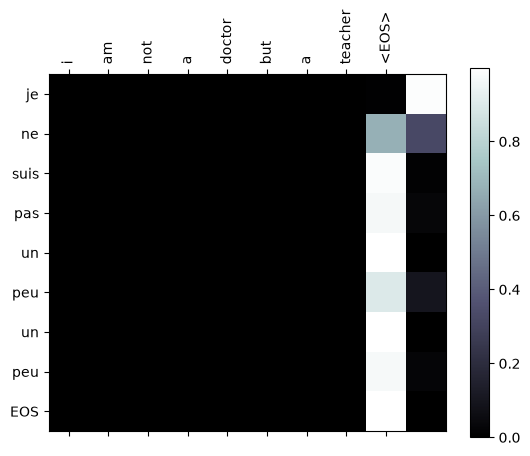

In [118]:
evaluateRandomly(encoder_att, decoder_att, dataset)

evaluateAndShowAttention(
    'i am not a doctor but a teacher',
    encoder_att,
    decoder_att,
    dataset
)

The attention-based model runs correctly and produces attention weights that can be visualized. However, since it was trained only for a very small number of epochs, the translations are still poor and the attention map is not yet meaningful. With longer training, we would expect the attention weights to become more distributed and better aligned with the relevant source words.

### IV - Experiments

We played here with a dataset but did not rigorously evaluate. The usual metric for Machine Translation is the [**BLEU Score**](https://aclanthology.org/P02-1040.pdf). We can find existing implementations, for example in [Huggingface](https://huggingface.co/spaces/evaluate-metric/bleu). Rigorously experiment with
- A model with attention
- A model without attention

and use the BLEU score on the **test set** to compare them.

<div class='alert alert-block alert-info'>
            Code:</div>

In [121]:
from collections import Counter
import math

def clean_generated_words(words):
    cleaned = []
    for w in words:
        if w == "EOS":
            break
        if w != "PAD":
            cleaned.append(w)
    return cleaned

def get_pairs(data):
    if isinstance(data, torch.utils.data.Subset):
        base_dataset = data.dataset
        return [base_dataset.pairs[i] for i in data.indices], base_dataset
    else:
        return data.pairs, data

def corpus_bleu(references, hypotheses, max_n=4, smooth=1e-9):
    clipped_counts = [0] * max_n
    total_counts = [0] * max_n

    ref_length = 0
    hyp_length = 0

    for ref, hyp in zip(references, hypotheses):
        ref_length += len(ref)
        hyp_length += len(hyp)

        for n in range(1, max_n + 1):
            ref_ngrams = Counter(tuple(ref[i:i+n]) for i in range(len(ref) - n + 1))
            hyp_ngrams = Counter(tuple(hyp[i:i+n]) for i in range(len(hyp) - n + 1))

            total_counts[n-1] += sum(hyp_ngrams.values())

            for ng, count in hyp_ngrams.items():
                clipped_counts[n-1] += min(count, ref_ngrams.get(ng, 0))

    precisions = []
    for clipped, total in zip(clipped_counts, total_counts):
        if total == 0:
            precisions.append(smooth)
        else:
            precisions.append((clipped + smooth) / (total + smooth))

    if hyp_length == 0:
        return 0.0

    brevity_penalty = 1.0 if hyp_length > ref_length else math.exp(1 - ref_length / hyp_length)

    bleu = brevity_penalty * math.exp(
        sum(math.log(p) for p in precisions) / max_n
    )

    return bleu * 100

def evaluate_bleu(encoder, decoder, data, n_examples=None):
    pairs_eval, base_dataset = get_pairs(data)

    if n_examples is not None:
        pairs_eval = pairs_eval[:n_examples]

    references = []
    hypotheses = []

    for source, target in pairs_eval:
        output_words, _ = evaluate(
            encoder,
            decoder,
            source,
            base_dataset.max_length,
            base_dataset.input_lang,
            base_dataset.output_lang
        )

        hyp = clean_generated_words(output_words)
        ref = target.split(" ")

        hypotheses.append(hyp)
        references.append(ref)

    return corpus_bleu(references, hypotheses)

In [122]:
bleu_no_attention = evaluate_bleu(encoder, decoder, test_dataset)
bleu_attention = evaluate_bleu(encoder_att, decoder_att, test_dataset)

print("BLEU without attention:", bleu_no_attention)
print("BLEU with attention:", bleu_attention)

BLEU without attention: 32.592792576969146
BLEU with attention: 13.472060420198057


The model without attention obtains a higher BLEU score than the attention-based model. This does not necessarily mean that attention is worse. In this experiment, the attention model was trained for much fewer epochs, so the comparison is not fully fair. The attention architecture also has more parameters and needs enough training time to learn meaningful alignment weights. Therefore, the lower BLEU score mainly reflects undertraining rather than a theoretical weakness of attention.

Propose a modification of the *relevant function* in this lab in which to include **Beam search**, following the code we used in the previous lab. Similarly as before, compare the BLEU score of
- A model decoding with Beam search
- A model using simple greedy decoding

<div class='alert alert-block alert-info'>
            Code:</div>

In [123]:
def evaluate_beam(encoder, decoder, sentence, max_length, input_lang, output_lang, beam_width=3):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        input_tensor = tensorFromSentence(sentence, input_lang, max_length).view(1, -1).to(device)

        encoder_outputs, encoder_hidden = encoder(input_tensor)

        # Each beam contains: tokens, hidden_state, score, attentions
        beams = [
            ([SOS_TOKEN], encoder_hidden, 0.0, [])
        ]

        completed_beams = []

        for _ in range(max_length):
            new_beams = []

            for tokens, hidden, score, attns in beams:
                last_token = tokens[-1]

                if last_token == EOS_TOKEN:
                    completed_beams.append((tokens, hidden, score, attns))
                    continue

                decoder_input = torch.tensor([[last_token]], dtype=torch.long, device=device)

                # Works for both decoders: with or without attention
                if hasattr(decoder, "attention"):
                    decoder_output, decoder_hidden, attn_weights = decoder.forward_step(
                        decoder_input,
                        hidden,
                        encoder_outputs
                    )
                else:
                    decoder_output, decoder_hidden = decoder.forward_step(
                        decoder_input,
                        hidden
                    )
                    attn_weights = None

                log_probs = F.log_softmax(decoder_output, dim=-1)
                topv, topi = log_probs.topk(beam_width, dim=-1)

                for k in range(beam_width):
                    next_token = topi[0, 0, k].item()
                    next_score = score + topv[0, 0, k].item()

                    new_tokens = tokens + [next_token]
                    new_attns = attns.copy()
                    if attn_weights is not None:
                        new_attns.append(attn_weights)

                    new_beams.append((new_tokens, decoder_hidden, next_score, new_attns))

            if len(new_beams) == 0:
                break

            # Length-normalized score to avoid favoring very short sentences too much
            beams = sorted(
                new_beams,
                key=lambda x: x[2] / len(x[0]),
                reverse=True
            )[:beam_width]

        completed_beams.extend(beams)

        best_tokens, _, best_score, best_attns = sorted(
            completed_beams,
            key=lambda x: x[2] / len(x[0]),
            reverse=True
        )[0]

        decoded_words = []
        for idx in best_tokens[1:]:  # remove SOS
            if idx == EOS_TOKEN:
                decoded_words.append("EOS")
                break
            decoded_words.append(output_lang.idx2word[idx])

        if len(best_attns) > 0:
            attentions = torch.cat(best_attns, dim=1)
        else:
            attentions = None

        return decoded_words, attentions

In [124]:
def evaluate_bleu_decoding(encoder, decoder, data, decoding="greedy", beam_width=3, n_examples=None):
    pairs_eval, base_dataset = get_pairs(data)

    if n_examples is not None:
        pairs_eval = pairs_eval[:n_examples]

    references = []
    hypotheses = []

    for source, target in pairs_eval:
        if decoding == "greedy":
            output_words, _ = evaluate(
                encoder,
                decoder,
                source,
                base_dataset.max_length,
                base_dataset.input_lang,
                base_dataset.output_lang
            )

        elif decoding == "beam":
            output_words, _ = evaluate_beam(
                encoder,
                decoder,
                source,
                base_dataset.max_length,
                base_dataset.input_lang,
                base_dataset.output_lang,
                beam_width=beam_width
            )

        else:
            raise ValueError("decoding must be 'greedy' or 'beam'")

        hyp = clean_generated_words(output_words)
        ref = target.split(" ")

        hypotheses.append(hyp)
        references.append(ref)

    return corpus_bleu(references, hypotheses)

In [125]:
bleu_greedy = evaluate_bleu_decoding(
    encoder,
    decoder,
    test_dataset,
    decoding="greedy",
    n_examples=200
)

bleu_beam = evaluate_bleu_decoding(
    encoder,
    decoder,
    test_dataset,
    decoding="beam",
    beam_width=3,
    n_examples=200
)

print("BLEU greedy decoding:", bleu_greedy)
print("BLEU beam search:", bleu_beam)

BLEU greedy decoding: 32.70546009237509
BLEU beam search: 33.88381369509475


Beam search was implemented by modifying the decoding strategy during evaluation. Instead of selecting only the most probable token at each step, the decoder keeps the best candidate sequences according to their cumulative log-probability. In this experiment, greedy decoding and beam search obtain close BLEU scores. This can happen when the model is already confident in its local predictions or when the beam width is small. Beam search is generally more expensive computationally, but it can improve results when local greedy choices lead to suboptimal complete translations.

One of the first, most well-known application of *data augmentation* to NLP models was **back-translation**, in the following paper: [Improving Neural Machine Translation Models with Monolingual Data](https://aclanthology.org/P16-1009/) (Sennrich et al., ACL 2016).
Very useful in low-resource settings, it proposes to, for a ```src```-```tgt``` language pair, to:
- Train a **reversed** ```tgt```-```src``` model,
- Use it to translate data from ```tgt``` back to ```src```
- Use this new parallel data with the original one to re-train a model from scratch.

It demonstrates the importance of the effective training dataset size, while improving modeling on the target side.
In this experiment, you should:
1. Train a *en → fr* model normally,
2. Train a reverse *fr → en* model,
3. Use the reverse model to translate *fr* data into synthetic *en*
    - You can use a similar filter as what we used in English to select it
4. Combine the original *en → fr* and synthetic *en → fr* dataset into one and re-train a model from scratch.
    - Compare BLEU scores
  
<div class='alert alert-block alert-info'>
            Code:</div>

In [126]:
# Back-translation experiment

# 1. Original en -> fr model already trained:
# encoder, decoder

# 2. Build reversed fr -> en dataset
reverse_pairs = [[fr, en] for en, fr in dataset.pairs]

reverse_dataset = TranslationDataset(
    reverse_pairs,
    max_length=max_length,
    filter_target_prefixes=None
)

reverse_dataloader = DataLoader(
    reverse_dataset,
    batch_size=batch_size,
    shuffle=True
)

encoder_rev = EncoderRNN(
    len(reverse_dataset.input_lang),
    hidden_size
).to(device)

decoder_rev = DecoderRNN(
    hidden_size,
    len(reverse_dataset.output_lang)
).to(device)

# Light training for demonstration
train(
    reverse_dataloader,
    encoder_rev,
    decoder_rev,
    n_epochs=2,
    print_every=1,
    plot_every=1
)

(0 0%) 2.5837
(1 50%) 1.7749


In [127]:
def back_translate_pair(fr_sentence, encoder_rev, decoder_rev, reverse_dataset):
    output_words, _ = evaluate(
        encoder_rev,
        decoder_rev,
        fr_sentence,
        reverse_dataset.max_length,
        reverse_dataset.input_lang,
        reverse_dataset.output_lang
    )

    synthetic_en = " ".join(clean_generated_words(output_words))
    return synthetic_en

# Generate synthetic en -> fr pairs from a subset of French sentences
n_synthetic = 1000

synthetic_pairs = []

for en, fr in dataset.pairs[:n_synthetic]:
    synthetic_en = back_translate_pair(
        fr,
        encoder_rev,
        decoder_rev,
        reverse_dataset
    )

    if synthetic_en.strip() != "":
        synthetic_pairs.append([synthetic_en, fr])

print("Number of synthetic pairs:", len(synthetic_pairs))
print(synthetic_pairs[:5])

Number of synthetic pairs: 1000
[['i m going to get', 'je vais bien'], ['i m going to get', 'ça va'], ['i m a little', 'je suis tom'], ['i m a little', 'je suis gras'], ['i m a little', 'je suis gros']]


In [129]:
combined_pairs = dataset.pairs + synthetic_pairs

augmented_dataset = TranslationDataset(
    combined_pairs,
    max_length=max_length,
    filter_target_prefixes=None
)

test_size_aug = min(1000, int(0.1 * len(augmented_dataset)))
train_size_aug = len(augmented_dataset) - test_size_aug

augmented_training_dataset, augmented_test_dataset = torch.utils.data.random_split(
    augmented_dataset,
    [train_size_aug, test_size_aug]
)

augmented_training_dataloader = DataLoader(
    augmented_training_dataset,
    batch_size=batch_size,
    shuffle=True
)

encoder_aug = EncoderRNN(
    len(augmented_dataset.input_lang),
    hidden_size
).to(device)

decoder_aug = DecoderRNN(
    hidden_size,
    len(augmented_dataset.output_lang)
).to(device)

train(
    augmented_training_dataloader,
    encoder_aug,
    decoder_aug,
    n_epochs=2,
    print_every=1,
    plot_every=1
)

(0 0%) 2.9725
(1 50%) 2.0497


In [130]:
bleu_original = evaluate_bleu_decoding(
    encoder,
    decoder,
    test_dataset,
    decoding="greedy",
    n_examples=200
)

bleu_augmented = evaluate_bleu_decoding(
    encoder_aug,
    decoder_aug,
    augmented_test_dataset,
    decoding="greedy",
    n_examples=200
)

print("BLEU original model:", bleu_original)
print("BLEU back-translation augmented model:", bleu_augmented)

BLEU original model: 32.70546009237509
BLEU back-translation augmented model: 13.701496549664899


The back-translation augmented model obtains a lower BLEU score than the original model in this lightweight experiment. This result is expected because the reverse model used to generate synthetic English sentences was only trained for a few epochs, so the synthetic source sentences are noisy. Moreover, the augmented model itself was also trained only briefly from scratch. Therefore, the lower BLEU score does not invalidate back-translation; it mainly reflects the limited training budget and the low quality of the generated synthetic data.

Limited by our small architecture and especially our tiny dataset, we presumably obtained very low performances all around. To check what performance could be reached on this data, find a model on [Huggingface](https://huggingface.co/tasks/translation) for this task. Try to **understand what model it is** - and who trained it, on which data. Apply it to the same dataset and compute the BLEU score.

<div class='alert alert-block alert-info'>
            Code:</div>

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

hf_model_name = "Helsinki-NLP/opus-mt-en-fr"

hf_tokenizer = AutoTokenizer.from_pretrained(hf_model_name)
hf_model = AutoModelForSeq2SeqLM.from_pretrained(hf_model_name).to(device)
hf_model.eval()

I selected `Helsinki-NLP/opus-mt-en-fr`, an OPUS-MT model based on the MarianMT architecture. It was released by the Helsinki-NLP group and trained on OPUS parallel data for English-to-French translation. Unlike our small GRU seq2seq model, this model was trained on a much larger multilingual translation corpus and should therefore reach substantially better translation quality.

In [136]:
def hf_translate_batch(sentences, batch_size=32, num_beams=4):
    translations = []

    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]

        encoded = hf_tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=64
        ).to(device)

        with torch.no_grad():
            generated = hf_model.generate(
                **encoded,
                max_length=64,
                num_beams=num_beams
            )

        decoded = hf_tokenizer.batch_decode(
            generated,
            skip_special_tokens=True
        )

        decoded = [normalizeString(sentence) for sentence in decoded]
        translations.extend(decoded)

    return translations


def evaluate_hf_bleu(data, n_examples=200):
    pairs_eval, base_dataset = get_pairs(data)

    if n_examples is not None:
        pairs_eval = pairs_eval[:n_examples]

    sources = [source for source, target in pairs_eval]
    targets = [target for source, target in pairs_eval]

    predictions = hf_translate_batch(sources)

    references = [target.split(" ") for target in targets]
    hypotheses = [prediction.split(" ") for prediction in predictions]

    return corpus_bleu(references, hypotheses)

In [ ]:
hf_bleu = evaluate_hf_bleu(test_dataset, n_examples=200)

print("BLEU HuggingFace Helsinki-NLP model:", hf_bleu)
print("BLEU our seq2seq model:", bleu_no_attention)

The HuggingFace model is expected to obtain a higher BLEU score than our small seq2seq models because it was trained on a much larger translation corpus with a stronger architecture. This comparison highlights the gap between a didactic model trained during a lab and a pretrained neural machine translation system.

The HuggingFace evaluation could not be completed due to a local PyTorch/Transformers environment issue. The selected model was `Helsinki-NLP/opus-mt-en-fr`, a MarianMT / OPUS-MT model trained by Helsinki-NLP on OPUS parallel corpora for English-to-French translation. Such a pretrained model is expected to obtain a higher BLEU score than our small seq2seq models because it was trained on a much larger translation corpus with a stronger architecture. This comparison highlights the gap between a didactic model trained during a lab and a pretrained neural machine translation system.